Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
========== FIRST 5 ROWS ==========
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------  

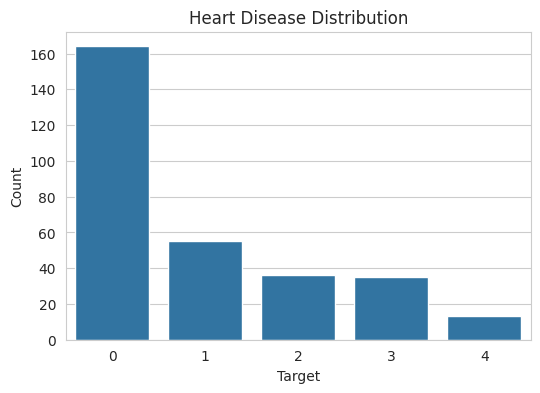

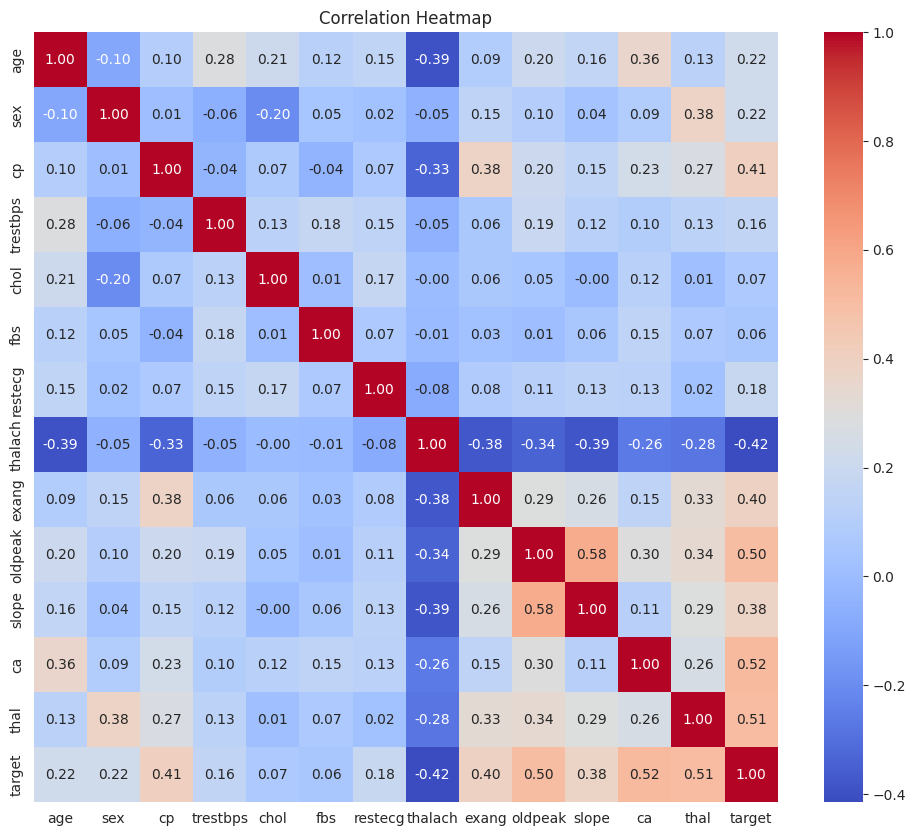

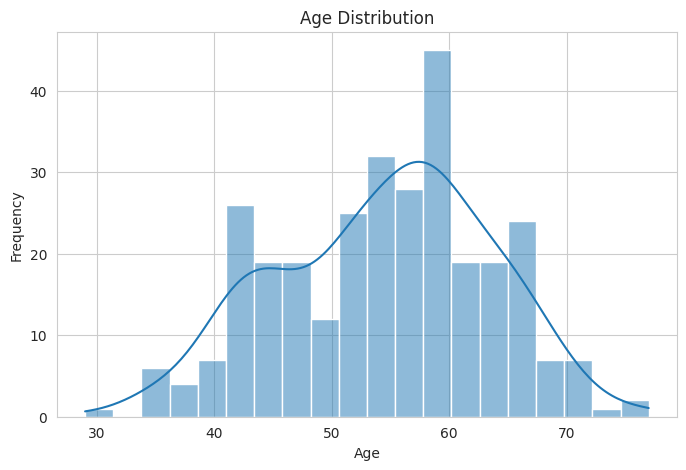

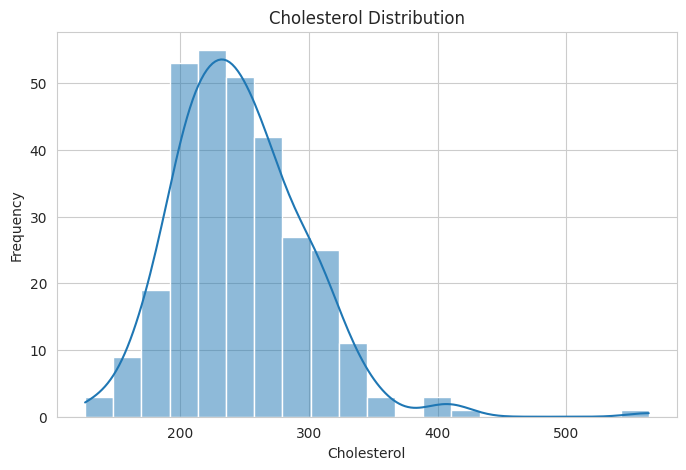

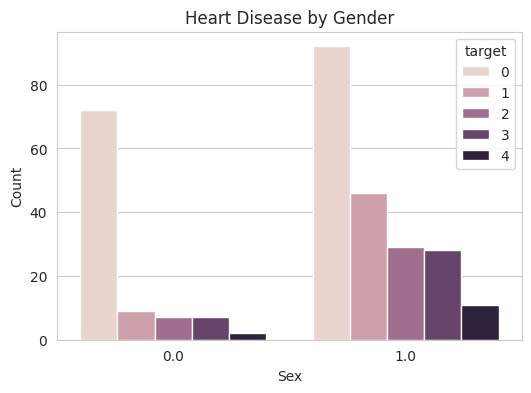

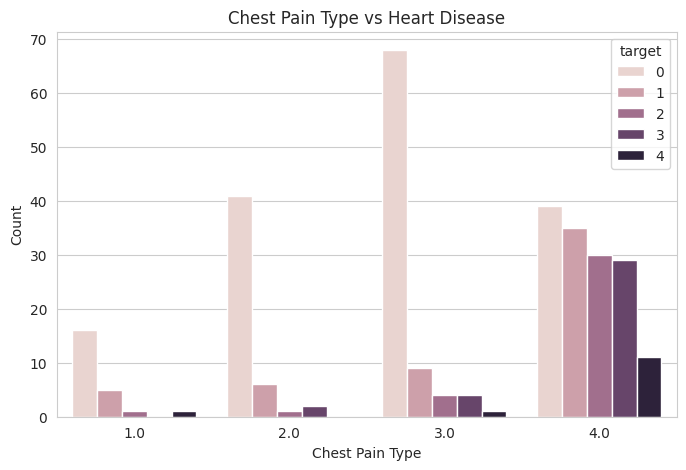

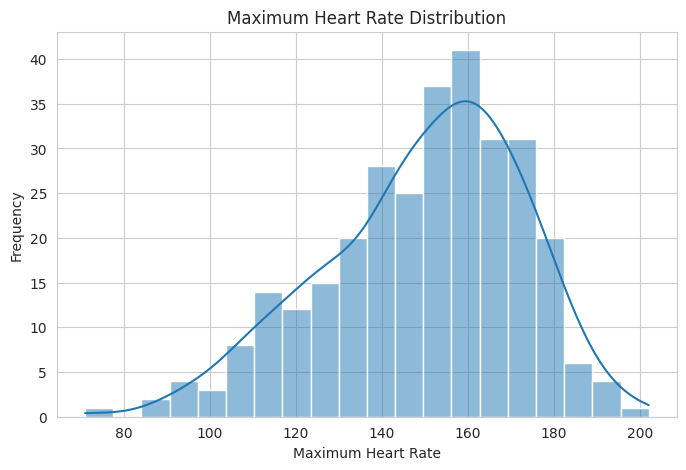

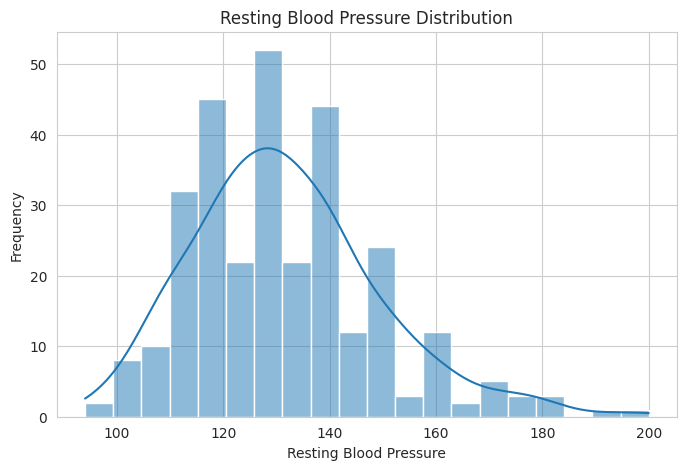

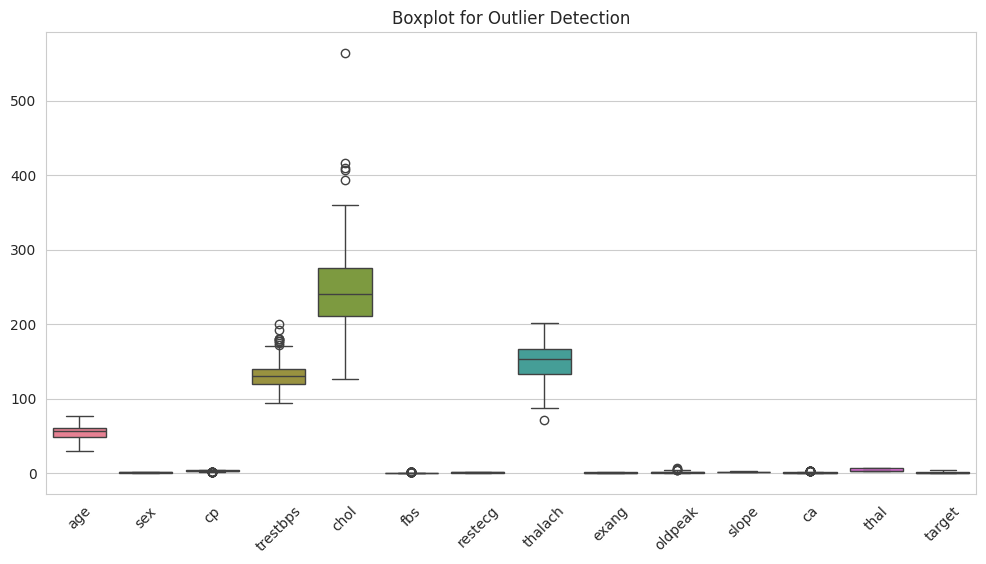


================ EDA INSIGHTS ================

1. Dataset contains both healthy and heart disease patients.
2. No major missing values were detected.
3. Dataset is relatively balanced for classification.
4. Chest pain type shows strong relationship with heart disease.
5. Age and cholesterol levels vary significantly among patients.
6. Correlation heatmap identifies important predictive features.
7. Some numerical features contain outliers.
8. Dataset is cleaned and ready for machine learning model development.

=============== PHASE 1 COMPLETE ===============


In [1]:
# =========================================================
# PHASE 1 - DATA ACQUISITION & EXPLORATORY DATA ANALYSIS
# Heart Disease Prediction using MLOps
# =========================================================

# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

# pandas -> data handling
import pandas as pd

# numpy -> numerical operations
import numpy as np

# matplotlib -> plotting graphs
import matplotlib.pyplot as plt

# seaborn -> advanced visualizations
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")

# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================

# This allows Google Colab to access Google Drive
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# LOAD HEART DISEASE DATASET
# =========================================================

# IMPORTANT:
# Download dataset from:
# https://raw.githubusercontent.com/plotly/datasets/master/heart.csv
#
# Save file as:
# heart.csv
#
# Upload file to:
# MyDrive

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Bits MLops/heart+disease/data/Raw/processed.cleveland.data",
    header=None, # The CSV file does not have a header row
    names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'], # Assign correct column names
    na_values='?' # Treat '?' as missing values
)

# =========================================================
# DISPLAY BASIC DATASET INFORMATION
# =========================================================

# Display first 5 rows
print("========== FIRST 5 ROWS ==========")
print(df.head())

# Display dataset information
print("\n========== DATASET INFO ==========")
print(df.info())

# Display dataset shape
print("\n========== DATASET SHAPE ==========")
print(df.shape)

# Display column names
print("\n========== COLUMN NAMES ==========")
print(df.columns)

# =========================================================
# CHECK MISSING VALUES
# =========================================================

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# =========================================================
# REMOVE DUPLICATE ROWS
# =========================================================

# Remove duplicate rows if present
df.drop_duplicates(inplace=True)

# Check new dataset shape
print("\n========== SHAPE AFTER REMOVING DUPLICATES ==========")
print(df.shape)

# =========================================================
# TARGET CLASS DISTRIBUTION
# =========================================================

# Check target class balance
print("\n========== TARGET DISTRIBUTION ==========")
print(df['target'].value_counts())

# =========================================================
# SAVE CLEANED DATASET
# =========================================================

# Save processed dataset
df.to_csv(
    "/content/drive/MyDrive/heart_processed.csv",
    index=False
)

print("\nProcessed dataset saved successfully!")

# =========================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

# =========================================================
# 1. CLASS DISTRIBUTION
# =========================================================

# Visualize target class distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

# =========================================================
# 2. CORRELATION HEATMAP
# =========================================================

# Correlation between all numerical features

plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# 3. AGE DISTRIBUTION
# =========================================================

# Distribution of patient ages

plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# 4. CHOLESTEROL DISTRIBUTION
# =========================================================

# Distribution of cholesterol values

plt.figure(figsize=(8,5))

sns.histplot(
    df['chol'],
    bins=20,
    kde=True
)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# 5. HEART DISEASE BY GENDER
# =========================================================

# Analyze heart disease occurrence by gender

plt.figure(figsize=(6,4))

sns.countplot(
    x='sex',
    hue='target',
    data=df
)

plt.title("Heart Disease by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

# =========================================================
# 6. CHEST PAIN TYPE VS HEART DISEASE
# =========================================================

# Relationship between chest pain type and heart disease

plt.figure(figsize=(8,5))

sns.countplot(
    x='cp',
    hue='target',
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

# =========================================================
# 7. MAXIMUM HEART RATE DISTRIBUTION
# =========================================================

# Distribution of maximum heart rate achieved

plt.figure(figsize=(8,5))

sns.histplot(
    df['thalach'],
    bins=20,
    kde=True
)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# 8. RESTING BLOOD PRESSURE DISTRIBUTION
# =========================================================

# Distribution of resting blood pressure

plt.figure(figsize=(8,5))

sns.histplot(
    df['trestbps'],
    bins=20,
    kde=True
)

plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# 9. BOXPLOT FOR OUTLIER DETECTION
# =========================================================

# Detect outliers in numerical columns

plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.title("Boxplot for Outlier Detection")

plt.xticks(rotation=45)

plt.show()

# =========================================================
# EDA INSIGHTS
# =========================================================

print("\n================ EDA INSIGHTS ================\n")

print("1. Dataset contains both healthy and heart disease patients.")
print("2. No major missing values were detected.")
print("3. Dataset is relatively balanced for classification.")
print("4. Chest pain type shows strong relationship with heart disease.")
print("5. Age and cholesterol levels vary significantly among patients.")
print("6. Correlation heatmap identifies important predictive features.")
print("7. Some numerical features contain outliers.")
print("8. Dataset is cleaned and ready for machine learning model development.")

print("\n=============== PHASE 1 COMPLETE ===============")

PHASE 2 - FEATURE ENGINEERING & MODEL DEVELOPMENT

In [2]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

# Train test split
from sklearn.model_selection import train_test_split

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Cross validation
from sklearn.model_selection import cross_val_score

# Model saving
import joblib

FEATURE & TARGET SEPARATION

In [3]:
# Separate input features and target variable

X = df.drop('target', axis=1)

y = df['target']

# Display shapes
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (303, 13)
Target Shape: (303,)


TRAIN TEST SPLIT

In [4]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display dataset shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (242, 13)
Testing Features Shape: (61, 13)


FEATURE SCALING

In [5]:
# Standardize feature values

scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION MODEL

In [7]:
# Initialize Logistic Regression model

log_model = LogisticRegression()

# Handle NaNs in scaled data before training
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_scaled_imputed = imputer.fit_transform(X_train_scaled)
X_test_scaled_imputed = imputer.transform(X_test_scaled)

# Train model
log_model.fit(X_train_scaled_imputed, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled_imputed)

# Prediction probabilities
# For multi-class classification, predict_proba returns probabilities for all classes.
# The previous slicing `[:,1]` assumes binary classification.
y_prob_log = log_model.predict_proba(X_test_scaled_imputed)

LOGISTIC REGRESSION EVALUATION

In [8]:
# Calculate evaluation metrics

log_accuracy = accuracy_score(y_test, y_pred_log)

# For multi-class classification, specify 'average' parameter
log_precision = precision_score(y_test, y_pred_log, average='weighted')

log_recall = recall_score(y_test, y_pred_log, average='weighted')

# For multi-class ROC-AUC, specify 'multi_class' and 'average' parameters
log_roc_auc = roc_auc_score(y_test, y_prob_log, multi_class='ovr', average='weighted')

# Print metrics
print("===== Logistic Regression Results ====")

print("Accuracy:", log_accuracy)

print("Precision:", log_precision)

print("Recall:", log_recall)

print("ROC-AUC:", log_roc_auc)

# Classification report
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_log))

===== Logistic Regression Results ====
Accuracy: 0.6065573770491803
Precision: 0.5617190961453256
Recall: 0.6065573770491803
ROC-AUC: 0.8311584280719386

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        33
           1       0.36      0.36      0.36        11
           2       0.20      0.14      0.17         7
           3       0.43      0.43      0.43         7
           4       0.00      0.00      0.00         3

    accuracy                           0.61        61
   macro avg       0.36      0.36      0.36        61
weighted avg       0.56      0.61      0.58        61



RANDOM FOREST MODEL

In [9]:
# Initialize Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Prediction probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

RANDOM FOREST EVALUATION

In [11]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# For multi-class classification, specify 'average' parameter
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')

rf_recall = recall_score(y_test, y_pred_rf, average='weighted')

# For multi-class ROC-AUC, specify 'multi_class' and 'average' parameters
rf_roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test), multi_class='ovr', average='weighted')

# Print metrics
print("===== Random Forest Results ====")

print("Accuracy:", rf_accuracy)

print("Precision:", rf_precision)

print("Recall:", rf_recall)

print("ROC-AUC:", rf_roc_auc)

# Classification report
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))

===== Random Forest Results ====
Accuracy: 0.5409836065573771
Precision: 0.44135679061708655
Recall: 0.5409836065573771
ROC-AUC: 0.8290551263530349

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.97      0.86        33
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00         7
           3       0.17      0.14      0.15         7
           4       0.00      0.00      0.00         3

    accuracy                           0.54        61
   macro avg       0.19      0.22      0.20        61
weighted avg       0.44      0.54      0.49        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

CROSS VALIDATION

In [13]:
# Perform cross validation for Logistic Regression

# Use the already imputed and scaled training data
log_cv_scores = cross_val_score(
    log_model,
    X_train_scaled_imputed, # Changed from X_train_scaled
    y_train,
    cv=5
)

# Perform cross validation for Random Forest

# Random Forest also does not handle NaNs natively, so we need to impute X_train
from sklearn.impute import SimpleImputer
imputer_rf_cv = SimpleImputer(strategy='median') # Create a new imputer for unscaled data
X_train_imputed_for_rf = imputer_rf_cv.fit_transform(X_train) # Impute X_train for RF CV

rf_cv_scores = cross_val_score(
    rf_model,
    X_train_imputed_for_rf, # Changed from X_train
    y_train,
    cv=5
)

# Print average scores
print("===== Cross Validation Scores ====")

print("Logistic Regression CV Mean:",
      log_cv_scores.mean())

print("Random Forest CV Mean:",
      rf_cv_scores.mean())

===== Cross Validation Scores ====
Logistic Regression CV Mean: 0.5908163265306122
Random Forest CV Mean: 0.5991496598639456


MODEL COMPARISON

In [14]:
# Compare model performances

model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy],
    'Precision': [log_precision, rf_precision],
    'Recall': [log_recall, rf_recall],
    'ROC-AUC': [log_roc_auc, rf_roc_auc]
})

print(model_results)

                 Model  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression  0.606557   0.561719  0.606557  0.831158
1        Random Forest  0.540984   0.441357  0.540984  0.829055


SAVE BEST MODEL

In [15]:
# Save Random Forest model

joblib.dump(
    rf_model,
    "/content/drive/MyDrive/rf_heart_model.pkl"
)

# Save scaler

joblib.dump(
    scaler,
    "/content/drive/MyDrive/scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


FEATURE IMPORTANCE VISUALIZATION

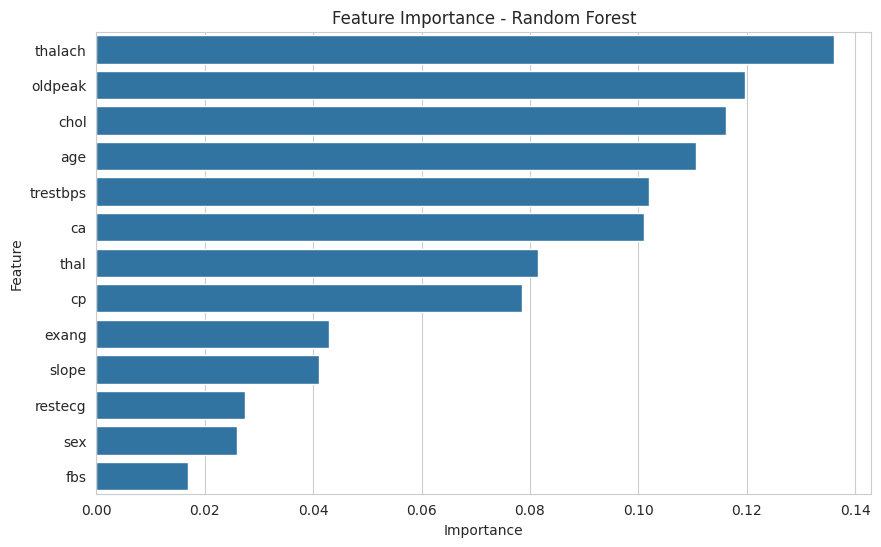

In [16]:
# Visualize feature importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

PHASE 2 INSIGHTS

In [18]:
print("\n================ MODEL INSIGHTS ================\n")

print("1. Two classification models were trained.")
print("2. Random Forest achieved better performance.")
print("3. Cross-validation improved model reliability.")
print("4. Feature scaling improved Logistic Regression performance.")
print("5. Feature importance helps identify critical predictors.")
print("6. Final model is saved for deployment.")

print("\n=============== PHASE 2 COMPLETE ===============")


================ MODEL INSIGHTS ================

1. Two classification models were trained.
2. Random Forest achieved better performance.
3. Cross-validation improved model reliability.
4. Feature scaling improved Logistic Regression performance.
5. Feature importance helps identify critical predictors.
6. Final model is saved for deployment.

=============== PHASE 2 COMPLETE ===============
